In [1]:
#load modules
from matplotlib import pyplot as plt
import numpy as np
from spectral1d import solve_nonlinear_problem # needed module
from overscreening_breakdown import overscreening_breakdown #needed module
from problem_with_discontinuous_coefficients import problem_discontinuous_lhs_1, \
problem_discontinuous_lhs_2, \
problem_discontinuous_lhs_3, \
problem_discontinuous_lhs_4

%matplotlib inline

In [2]:
problem_discontinuous_lhs1 = problem_discontinuous_lhs_1()
problem_discontinuous_lhs2 = problem_discontinuous_lhs_2()
problem_discontinuous_lhs3 = problem_discontinuous_lhs_3()
problem_discontinuous_lhs4 = problem_discontinuous_lhs_4()

def some_func(x):
    return 1/(1+x)

problem_discontinuous_lhs1.set_parameters(initial_guess_solution=some_func)
problem_discontinuous_lhs2.set_parameters(initial_guess_solution=some_func)
problem_discontinuous_lhs3.set_parameters(initial_guess_solution=some_func)
problem_discontinuous_lhs4.set_parameters(initial_guess_solution=some_func)

In [3]:
N = 100
domain = [0,np.inf]
tolerance = 1.0e-10
use_method = "newton"
use_adjoint_opimization = False
use_globalization = False
L = 6 #on the sellection of this parameter, see bellow 

solver = solve_nonlinear_problem(N=N, 
                                 domain=domain, 
                                 tolerance=tolerance, 
                                 use_method=use_method, 
                                 use_adjoint_opimization = use_adjoint_opimization, 
                                 use_globalization = use_globalization)
solver.set_mapping_parameter(L)

In [4]:
def plot_all(c, problem):
    #plotting in computational domain in [0, $pi$]
    t = np.arange(0, np.pi, 0.01) 
    sol = solver.obtain_solution_in_basis(c, t)
    plt.title("solution on the mapped segment [0,$\pi$]")
    plt.plot(t, sol,'.')
    plt.legend(["discont. LHS"])
    plt.show()

    #plotting in physical domain for 0<=x<=100
    x = np.arange(0, 10, 0.005)
    sol = solver.obtain_solution_in_domain(c, x)
    plt.title("solution on the part of the $\mathbb{R}^+$")
    plt.plot(x, sol, '.')
    plt.legend(["discont. LHS"])
    plt.show()


    #plotting the rhs of the problem
    x = np.arange(0.0,2.0, 0.01)
    sol = solver.obtain_solution_in_domain(c, x)
    rhs = problem.right_hand_side(x,sol,0)
    plt.title("rhs near discontinuity")
    plt.plot(x, rhs, '.')
    plt.legend(["discont. RHS"])
    plt.show()    

test for the 2-nd derivative with manufactured solution exp(-x) and discontinuous coefficient if(x<1,1,10).
$eps(x)u_{xx}=f(x,u)-g(x)$, $u=exp(-x)$
newton: relative target tolerance = 1.009950e-09
newton: iteration  1 , residual norm 2.111669e-03 , weight = 1.000000e+00
newton: iteration  2 , residual norm 1.085641e-07 , weight = 1.000000e+00
newton: iteration  3 , residual norm 5.329845e-16 , weight = 1.000000e+00
converged with norm = 5.329845e-16


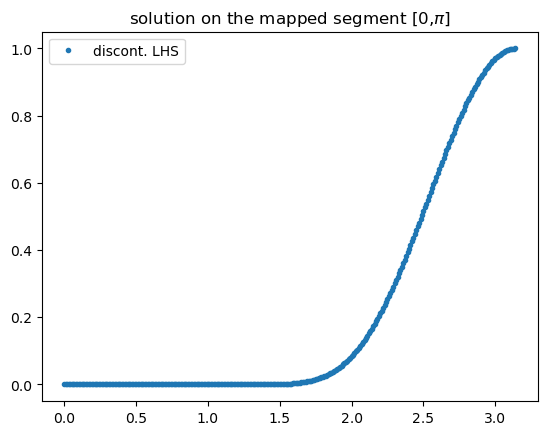

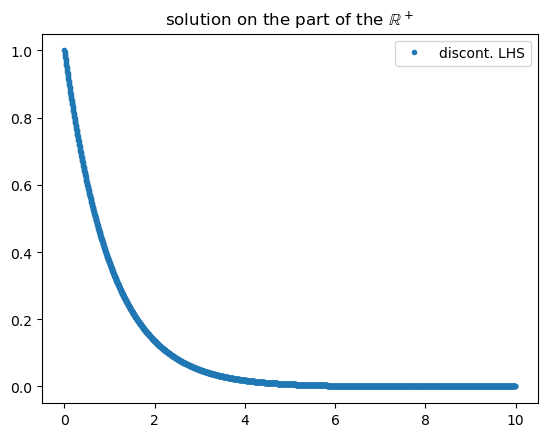

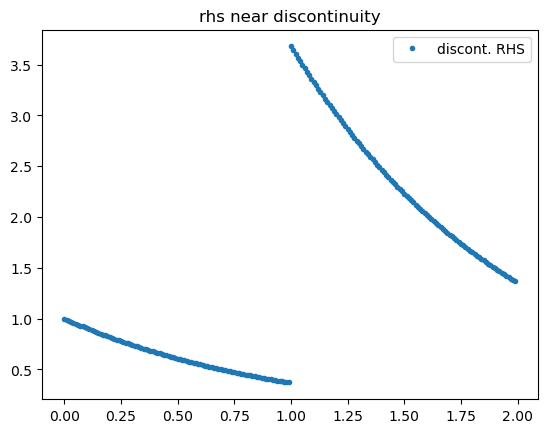

test for the 4-th derivative with manufactured solution exp(-x) and discontinuous coefficient if(x<1,1,10).
$eps(x)u_{xxxx}=f(x,u)-g(x)$, $u=exp(-x)$
newton: relative target tolerance = 1.009950e-09
newton: iteration  1 , residual norm 2.108010e-03 , weight = 1.000000e+00
newton: iteration  2 , residual norm 1.821538e-07 , weight = 1.000000e+00
newton: iteration  3 , residual norm 6.428167e-13 , weight = 1.000000e+00
converged with norm = 6.428167e-13


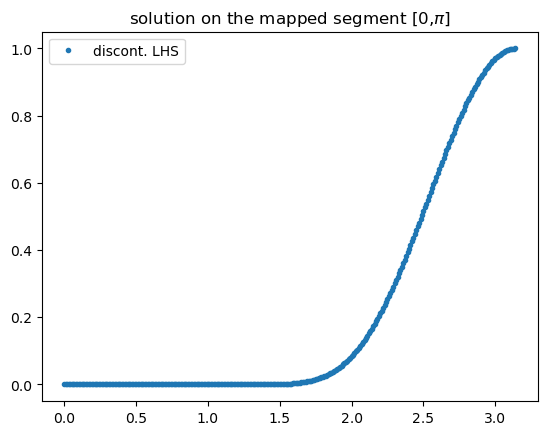

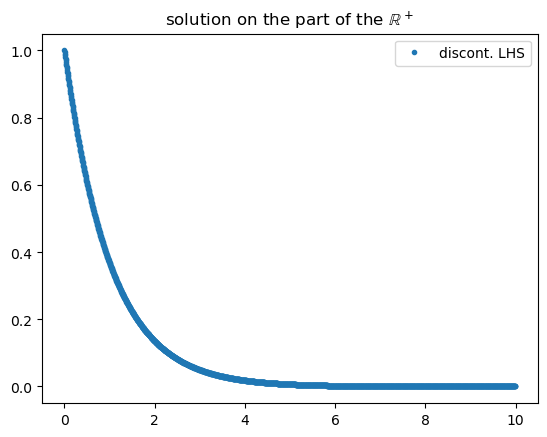

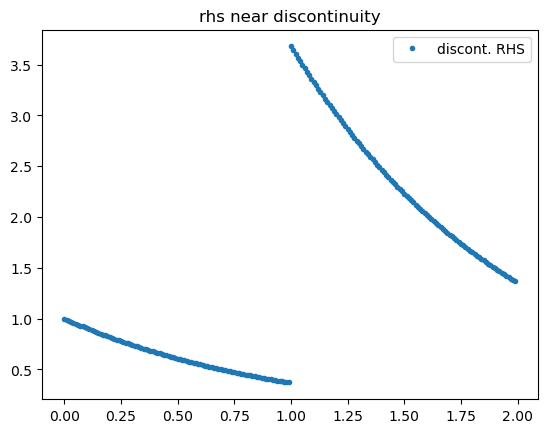

test for the 2-nd derivative with and discontinuous coefficient if(x<1,1,1000).
$eps(x)u_{xx}=sinh(u)$, $u=exp(-x)$
newton: relative target tolerance = 1.009950e-09
newton: iteration  1 , residual norm 9.603187e-03 , weight = 1.000000e+00
newton: iteration  2 , residual norm 3.270527e-07 , weight = 1.000000e+00
newton: iteration  3 , residual norm 1.411286e-14 , weight = 1.000000e+00
converged with norm = 1.411286e-14


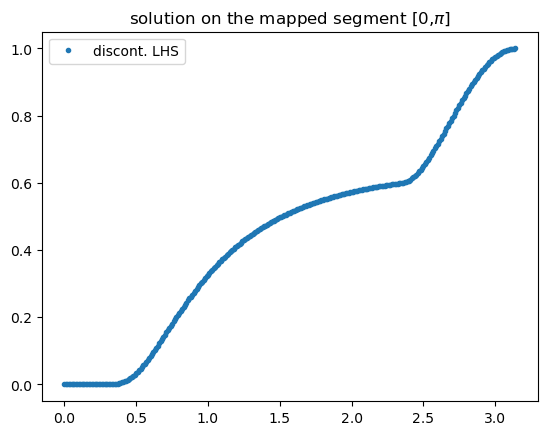

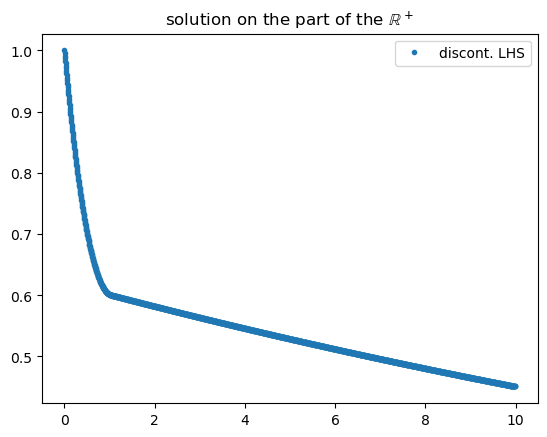

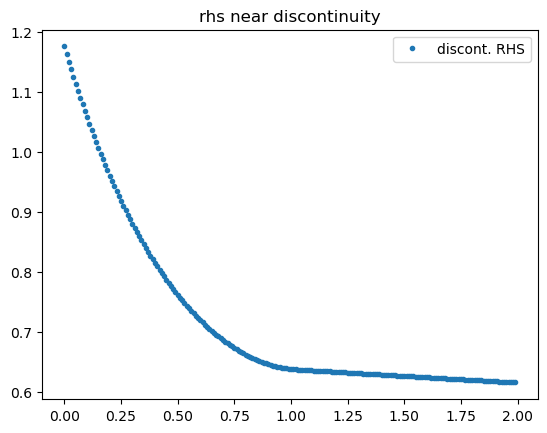

test for the 4-nd derivative with and discontinuous coefficient if(x<1,1,1000).
$eps(x)u_{xxxx}=sinh(u)$, $u=exp(-x)$
newton: relative target tolerance = 1.009950e-09
newton: iteration  1 , residual norm 1.806931e-01 , weight = 1.000000e+00
newton: iteration  2 , residual norm 8.055746e-04 , weight = 1.000000e+00
newton: iteration  3 , residual norm 4.712764e-08 , weight = 1.000000e+00
newton: iteration  4 , residual norm 2.552710e-11 , weight = 1.000000e+00
converged with norm = 2.552710e-11


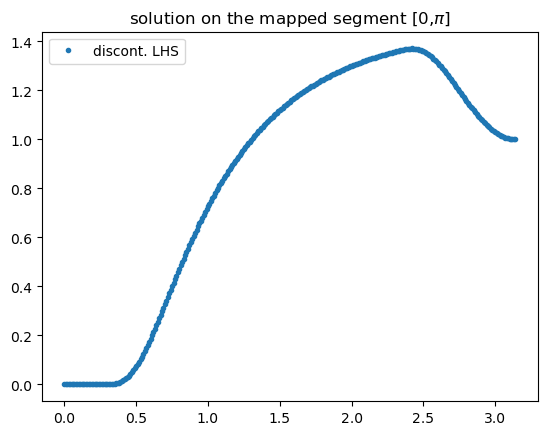

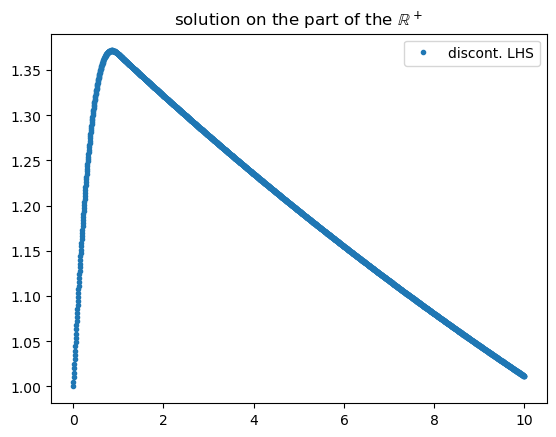

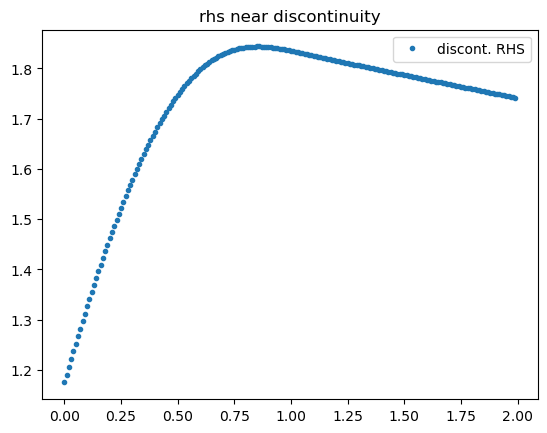

done.


In [5]:
for problem in [problem_discontinuous_lhs1, problem_discontinuous_lhs2, problem_discontinuous_lhs3, problem_discontinuous_lhs4]:
    print(problem.info())
    print(problem.get_name())
    solver.set_problem(problem)
    c = solver.solve_problem()
    plot_all(c, problem)
print("done.")